In [56]:
import pickle as pkl
import torch
import torch.nn as nn
import torch.optim as optim
from nltk.corpus import brown
from nltk import download
from torch.utils.data import DataLoader, Dataset
from collections import Counter
import random
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import json

torch.manual_seed(42)

In [57]:
import importlib
import enc_dec_lstm
importlib.reload(enc_dec_lstm)
from enc_dec_lstm import Encoder, Decoder, Encoder_Decoder_Model

In [ ]:
device = "xpu" if torch.xpu.is_available() else "cpu"
device

'cuda'

In [ ]:
with open('../data/test_data.pkl', 'rb') as f:
    test_data = pkl.load(f)

In [ ]:
with open('tokenizer/word2idx.json', 'r') as f:
    word2idx = json.load(f)
    idx2word = {v: k for k, v in word2idx.items()}
with open('tokenizer/tag2idx.json', 'r') as f:
    tag2idx = json.load(f)
    idx2tag = {v: k for k, v in tag2idx.items()}
with open("tokenizer/word_embeddings.pt", "rb") as f:
    train_embeddings = torch.load(f)

In [61]:
vocab_size = len(word2idx)
tag_size = len(tag2idx)

In [62]:
class POSTagDataset(Dataset):
    def __init__(self, sentences):
        self.data = []
        for sent in sentences:
            words, tags = zip(*sent)
            
            word_ids = [word2idx.get(w, 1) for w in words]
            tag_ids = [tag2idx.get(t, 0) if t in tag2idx else 0 for t in tags]

            length = len(word_ids)

            self.data.append((torch.tensor(word_ids).to(device), torch.tensor(tag_ids).to(device), length))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

In [63]:
test_dataset = POSTagDataset(test_data)

In [64]:
batch_size=128
test_loader = DataLoader(test_dataset, batch_size=1)

In [ ]:
epochs = 30
embed_dim = 300
hidden_dim = 256
model=Encoder_Decoder_Model(vocab_size, embed_dim, hidden_dim, tag_size, tag2idx["<SOS>"], train_embeddings).to(device)
lr=0.001
model.load_state_dict(torch.load(f'models/encoder_decoder_model_{lr}lr_{batch_size}bs_{epochs}epochs.pth', map_location=device))

<All keys matched successfully>

In [80]:
preds=[]
actuals=[]

In [81]:
count=-100

In [82]:
model.eval()
with torch.no_grad():
    for test_batch in tqdm(test_loader, desc="Testing", total=len(test_loader)):
        words_batch, tags_batch, length_batch = test_batch
        input_seq = words_batch
        output_tags = model.generate(input_seq, words_batch.shape[1], length_batch)
        tags=[[idx2tag[idx.item()] for idx in output_tags[i]] for i in range(len(output_tags))]
        preds+=tags[0][1:]
        actuals+=[idx2tag[idx.item()] for idx in tags_batch[0]]
        if count==0:
            break
        count-=1

Testing: 100%|██████████| 5734/5734 [03:14<00:00, 29.49it/s]


In [83]:
len(preds), len(actuals)

(115827, 115827)

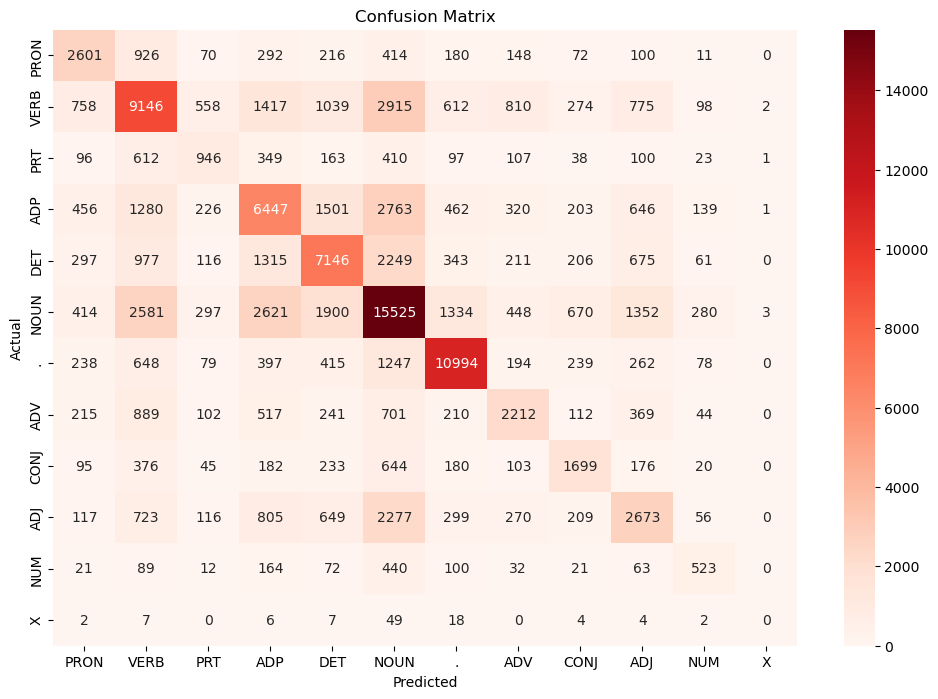

In [84]:
confusion_matrix_data = confusion_matrix(actuals, preds, labels=list(tag2idx.keys())[:-2])
plt.figure(figsize=(12, 8))
sns.heatmap(
    confusion_matrix_data,
    annot=True,
    cmap="Reds",
    fmt="d",
    xticklabels=list(tag2idx.keys())[:-2],
    yticklabels=list(tag2idx.keys())[:-2],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

In [85]:
print(classification_report(
    actuals, preds, labels=list(tag2idx.keys())[:-2], digits=4
))

              precision    recall  f1-score   support

        PRON     0.4898    0.5171    0.5031      5030
        VERB     0.5010    0.4970    0.4990     18404
         PRT     0.3685    0.3215    0.3434      2942
         ADP     0.4443    0.4463    0.4453     14444
         DET     0.5261    0.5256    0.5259     13596
        NOUN     0.5239    0.5661    0.5442     27425
           .     0.7414    0.7433    0.7423     14791
         ADV     0.4556    0.3942    0.4227      5612
        CONJ     0.4534    0.4527    0.4531      3753
         ADJ     0.3715    0.3262    0.3474      8194
         NUM     0.3918    0.3403    0.3642      1537
           X     0.0000    0.0000    0.0000        99

    accuracy                         0.5173    115827
   macro avg     0.4389    0.4275    0.4325    115827
weighted avg     0.5144    0.5173    0.5153    115827

